In [18]:
!git clone https://github.com/beckhamtoh/char-llm-assignment.git
%cd char-llm-assignment

Cloning into 'char-llm-assignment'...


/usr/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


remote: Enumerating objects: 244, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 244 (delta 20), reused 34 (delta 11), pack-reused 197 (from 1)
Receiving objects: 100% (244/244), 36.22 MiB | 23.05 MiB/s, done.
Resolving deltas: 100% (115/115), done.
/kaggle/working/char-llm-assignment/char-llm-assignment


In [19]:
# manual reload for local modules
import importlib

In [20]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import numpy as np
import jax
import jax.numpy as jnp
import optax
import time
import pandas as pd
import matplotlib.pyplot as plt

# local imports
import models.models as models
import util.generation as generation


In [21]:
# initialize the jax random key
key = jax.random.key(0)

# Load data

In [22]:
# load the ./data/text8_train.txt and ./data/text8_test.txt files
with open("./data/text8_train.txt", "r") as f:
    train_text = f.read()
with open("./data/text8_test.txt", "r") as f:
    test_text = f.read()

# print the length of the training text and test text
print(f"Length of training text: {len(train_text):_} characters")
print(f"Length of test text: {len(test_text):_} characters")

Length of training text: 90_000_000 characters
Length of test text: 5_000_000 characters


In [23]:
# Build vocabulary (lowercase + space + a few punctuations)
char_set = list("abcdefghijklmnopqrstuvwxyz ")
char_to_int = {ch:i for i,ch in enumerate(char_set)}
int_to_char = {i:ch for ch,i in char_to_int.items()}

def encode(s):
    """Encode string to array of integers"""
    ids = [char_to_int[c] for c in s]
    return np.array(ids, dtype=np.uint8)  # use np.uint8 to save space

In [24]:
# encode the text
train_text_int = encode(train_text)
test_text_int = encode(test_text)

In [25]:
# sanity check: display a few random characters from the training text
T = 128
for _ in range(5):
    # choose random position in text
    N = np.random.randint(low=0, high=len(train_text)-T)
    print(train_text[N:N+T])
    print()

thic old cathedral of lleida la seu vella lleida catalan spanish l rida although officially referred as lleida is a city in the 

 the following four two countries albania australia belgium benin bulgaria cameroon canada china congo denmark estonia finland f

the shatz for each prayer session if there is no standard shatz and makes certain that the synagogue is kept clean and supplied 

und the world animators are all forced to conform to a set style by the director or animation director in japan starting with th

ist recipient of the nobel prize in physiology or medicine d one nine eight two one nine zero seven frida kahlo mexican painter 



# Model and Helper Functions

In [26]:
def create_train_state(rng, vocab_size=27, d_model=64, n_layers=6, n_heads=8, max_len=128):
    """
    Create a Transformer model and initialize its parameters.
    
    Args:
        rng: JAX random key for initialization
        vocab_size: Number of unique tokens (27 for our character set)
        d_model: Hidden dimension size (width of the model)
        n_layers: Number of transformer layers (depth of the model)
        n_heads: Number of attention heads
        max_len: Maximum sequence length the model can handle
    
    Returns:
        model: The Transformer model object
        params: Initialized model parameters
    """
    # Create a decoder-only Transformer (like GPT)
    model = models.DecoderOnlyTransformer(vocab_size, d_model, n_layers, n_heads, max_len)
    
    # Create a dummy input to initialize parameters
    dummy = jnp.zeros((1, min(16, max_len)), dtype=jnp.int32)
    
    # Initialize parameters by running a forward pass with the dummy input
    params = model.init({"params": rng}, dummy)["params"]
    return model, params


def count_params(params):
    """
    to count the total number of trainable parameters in the model.
    
    important for scaling laws because performance scales
    with model size (number of parameters N).
    
    Args:
        params: PyTree of model parameters
    Returns:
        Total number of parameters as an integer
    """
    # Flatten the parameter tree and sum all parameter sizes
    return sum(x.size for x in jax.tree_util.tree_leaves(params))


@jax.jit
def loss_and_metrics(logits, targets):
    """
    Compute cross-entropy loss and accuracy metrics.
    
    Args:
        logits: Model outputs of shape (B, T, V) where V is vocab size
        targets: Ground truth labels of shape (B, T)
    
    Returns:
        loss: Scalar cross-entropy loss averaged over all positions
        metrics: Dictionary containing loss, accuracy, and last-position accuracy
    """
    vocab = logits.shape[-1]
    
    # Flatten batch and time dimensions for loss computation
    # (B, T, V) -> (B*T, V)
    flat_logits = logits.reshape(-1, vocab)
    # (B, T) -> (B*T,)
    flat_targets = targets.reshape(-1)
    
    # Compute per-position cross-entropy loss
    per_pos = optax.softmax_cross_entropy_with_integer_labels(flat_logits, flat_targets)
    loss = per_pos.mean()
    
    # Compute predictions by taking argmax over vocabulary
    preds = jnp.argmax(logits, axis=-1)  # (B, T)
    is_match = preds == targets
    
    # Accuracy over all positions
    acc_all = jnp.mean(is_match.astype(jnp.float32))
    
    # Accuracy over only the last position
    # This measures how well the model predicts the next character
    acc_last = jnp.mean(is_match.astype(jnp.float32)[:,-1])
    
    return loss, {"loss": loss, "acc": acc_all, "acc_last": acc_last}


def get_batch(text_int, B, T):
    """
    Create a random batch of training data.
    
    For language modeling, we predict the next character at each position.
    Input: characters 0 to T-1
    Target: characters 1 to T
    
    Args:
        text_int: 1D array of encoded text
        B: Batch size (number of sequences)
        T: Sequence length (context window)
    
    Returns:
        x: Input sequences of shape (B, T)
        y: Target sequences of shape (B, T)
    """
    # Randomly choose starting positions for each sequence
    ix = np.random.randint(0, len(text_int) - T, size=B)
    
    # Extract input sequences (positions i to i+T-1)
    x = np.stack([text_int[i:i+T] for i in ix])
    
    # Extract target sequences (positions i+1 to i+T)
    # This is shifted by 1 from input for next-character prediction
    y = np.stack([text_int[i+1:i+T+1] for i in ix])
    
    return jnp.array(x, dtype=jnp.int32), jnp.array(y, dtype=jnp.int32)

# Experiment Configurations

In [27]:
# Global settings used across all experiments
vocab_size = len(char_set)  # 27 characters
max_len = 128  # Maximum context length
learning_rate = 0.001  # Adam learning rate

# Define configurations to test
# Each configuration specifies a different model architecture and training setup
# 
# Key insight from scaling laws paper:
# - Performance depends on N (parameters), D (data), and C (compute)
# - We want to find which configuration achieves best performance at convergence
# - Larger models may look worse early but converge to better final performance

configurations = [
    # ==========================================================================
    # STAGE 1: MODEL SIZE SCALING (FIXED B=128, T=32)
    # ==========================================================================
    {"d_model": 64,  "n_layers": 2, "n_heads": 2, "B": 128, "T": 32, "name": "xs"},
    {"d_model": 128, "n_layers": 2, "n_heads": 2, "B": 128, "T": 32, "name": "s"},
    {"d_model": 128, "n_layers": 4, "n_heads": 4, "B": 128, "T": 32, "name": "s_deep"},
    {"d_model": 256, "n_layers": 2, "n_heads": 4, "B": 128, "T": 32, "name": "m"},
    {"d_model": 256, "n_layers": 4, "n_heads": 4, "B": 128, "T": 32, "name": "m_deep"},
    {"d_model": 512, "n_layers": 2, "n_heads": 8, "B": 128, "T": 32, "name": "l"},
    {"d_model": 512, "n_layers": 4, "n_heads": 8, "B": 128, "T": 32, "name": "l_deep"},
    
    # ==========================================================================
    # STAGE 2: BATCH SIZE (FIXED model=m_deep, T=32)
    # ==========================================================================
    {"d_model": 256, "n_layers": 4, "n_heads": 4, "B": 64,  "T": 32, "name": "B64"},
    {"d_model": 256, "n_layers": 4, "n_heads": 4, "B": 256, "T": 32, "name": "B256"},
    {"d_model": 256, "n_layers": 4, "n_heads": 4, "B": 512, "T": 32, "name": "B512"},
    
    # ==========================================================================
    # STAGE 3: SEQUENCE LENGTH (FIXED model=m_deep, B=128)
    # ==========================================================================
    {"d_model": 256, "n_layers": 4, "n_heads": 4, "B": 128, "T": 16,  "name": "T16"},
    {"d_model": 256, "n_layers": 4, "n_heads": 4, "B": 128, "T": 64,  "name": "T64"},

    # ==========================================================================
    # STAGE 4: Best Model 
    # ==========================================================================   
    {"d_model": 512, "n_layers": 4, "n_heads": 8, "B": 256, "T": 64, "name": "best1"},
    {"d_model": 256, "n_layers": 4, "n_heads": 4, "B": 256, "T": 64, "name": "best2"},
]

# Add computed fields to each configuration
for config in configurations:
    # Head dimension = model dimension / number of heads
    # This determines how much information each attention head can store
    config['head_dim'] = config['d_model'] // config['n_heads']

# Display configuration summary
print(f"Total configurations to test: {len(configurations)}")
print(pd.DataFrame(configurations)[['name', 'd_model', 'n_layers', 'n_heads', 'B', 'T', 'head_dim']])

Total configurations to test: 14
      name  d_model  n_layers  n_heads    B   T  head_dim
0       xs       64         2        2  128  32        32
1        s      128         2        2  128  32        64
2   s_deep      128         4        4  128  32        32
3        m      256         2        4  128  32        64
4   m_deep      256         4        4  128  32        64
5        l      512         2        8  128  32        64
6   l_deep      512         4        8  128  32        64
7      B64      256         4        4   64  32        64
8     B256      256         4        4  256  32        64
9     B512      256         4        4  512  32        64
10     T16      256         4        4  128  16        64
11     T64      256         4        4  128  64        64
12   best1      512         4        8  256  64        64
13   best2      256         4        4  256  64        64


# Training Function

In [28]:
def train_model_scaling_laws(config, train_text_int, test_text_int, vocab_size, max_len, learning_rate):
    """
    Train a model using a fixed compute budget instead of fixed iterations.
    
    The scaling laws paper shows that performance scales with compute C ≈ 6NBS
    where N is the number of model parameters, B is batch size, S is number of training steps. 
    (Kaplan et al., 2020)
    
    If we train all models for the same number of iterations, larger models get
    MORE compute (because they do more FLOPs per iteration). This unfairly
    advantages larger models.
    
    By fixing the total compute budget, we ensure a fair comparison:
    - Small models: many iterations, less compute per iteration
    - Large models: fewer iterations, more compute per iteration
    - Total compute: SAME for all models
    
    This shows which model architecture is most compute-efficient.
    
    Args:
        config: Dictionary with model and training configuration
        train_text_int: Encoded training text
        test_text_int: Encoded test text
        vocab_size: Size of vocabulary
        max_len: Maximum sequence length
        learning_rate: Learning rate for optimizer
    
    Returns:
        result: Dictionary with training results and history
        params: Trained model parameters
    """
    B = config['B']  # Batch size
    T = config['T']  # Sequence length
    
    print(f"\n{'='*70}")
    print(f"Training: {config['name']}")
    print(f"  d_model={config['d_model']}, n_layers={config['n_layers']}, n_heads={config['n_heads']}")
    print(f"  B={B}, T={T}")
    print(f"{'='*70}")
    
    # Create model with specified architecture
    model, params = create_train_state(
        key, vocab_size, config['d_model'], config['n_layers'], config['n_heads'], max_len
    )
    
    n_params = count_params(params)
    print(f"  Parameters: {n_params:,}")
    
    # ==========================================================================
    # COMPUTE BUDGET CALCULATION
    # ==========================================================================
    # C ≈ 6 * N * B * T per training step
    # - Factor of 6 accounts for forward pass (2x) and backward pass (4x)
    # - N is number of parameters
    # - B is batch size
    # - T is sequence length
    
    compute_budget = 5e14  # Total FLOPs to use (adjusted accordingly based on test runs we tried)
    flops_per_iter = 6 * n_params * B * T
    max_iters = int(compute_budget / flops_per_iter)

    # Safety cap to prevent extremely long runs
    # Happened for smaller models where it would run for more than 100000 iterations
    # We deemed it unnecessary since the loss plateau-ed way before 100000 iterations
    
    max_iters = min(max_iters, 50000)

    # However, we found that some models had L∞ = 0
    # best1, best2, best3, T128 models
    # This is because of the lack of iterations, resulting in a poor fit of the model
    # Which is generally not possible of a model to obtain asymptotic loss of 0
    # Hence we should set a min iteration of at least 2000
    
    max_iters = max(max_iters, 2000)
    
    print(f"  FLOPs/iter: {flops_per_iter:.2e}")
    print(f"  Max iterations: {max_iters:,}")
    
    # Setup Adam optimizer
    tx = optax.adam(learning_rate=learning_rate)
    opt_state = tx.init(params)
    
    # Define training step function (must be inside to capture 'model')
    def train_step_local(params, opt_state, x, y):
        """Single training step: forward pass, loss, backward pass, update."""
        def loss_fn(params):
            logits = model.apply({"params": params}, x)
            loss, metrics = loss_and_metrics(logits, y)
            return loss, metrics
        
        # Compute gradients with respect to parameters
        (loss, metrics), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)
        
        # Apply optimizer update
        updates, new_opt_state = tx.update(grads, opt_state, params)
        new_params = optax.apply_updates(params, updates)
        
        return new_params, new_opt_state, metrics
    
    # JIT compile the training step for speed
    train_step_jitted = jax.jit(train_step_local)
    
    # ==========================================================================
    # HISTORY TRACKING
    # ==========================================================================
    # We track metrics at multiple points during training to fit scaling laws
    history = {
        'iteration': [],      # Training step number
        'compute': [],        # Cumulative FLOPs used
        'test_loss': [],      # Test set loss
        'test_acc_last': []   # Test set accuracy (last position)
    }
    
    # Create checkpoints at evenly spaced intervals
    # We need multiple points to fit the power-law curve
    n_checkpoints = 20
    checkpoint_iters = set([int(max_iters * x) for x in np.linspace(0.05, 1.0, n_checkpoints)])
    checkpoint_iters.add(0)  # Also record initial state
    
    B_test, T_test = 1024, T  # Larger batch for more stable test evaluation
    time_start = time.time()
    
    # ==========================================================================
    # TRAINING LOOP
    # ==========================================================================
    for it in range(max_iters + 1):
        # Get a random batch of training data
        batch = get_batch(train_text_int, B, T)
        input_batch, target = batch[0], batch[1]
        
        # Perform one training step
        params, opt_state, metrics = train_step_jitted(params, opt_state, input_batch, target)
        
        # Record metrics at checkpoint iterations
        if it in checkpoint_iters:
            # Calculate cumulative compute used so far
            cumulative_compute = (it + 1) * flops_per_iter
            
            # Evaluate on test set
            test_batch = get_batch(test_text_int, B_test, T_test)
            test_input, test_target = test_batch[0], test_batch[1]
            test_logits = model.apply({"params": params}, test_input)
            test_loss, test_metrics = loss_and_metrics(test_logits, test_target)
            
            # Record history for scaling law fitting
            history['iteration'].append(it)
            history['compute'].append(cumulative_compute)
            history['test_loss'].append(float(test_loss))
            history['test_acc_last'].append(float(test_metrics['acc_last']))
            
            # Print progress at major checkpoints
            if it % max(1, max_iters // 5) == 0 or it == max_iters:
                print(f"  iter {it:>6,} | C={cumulative_compute:.2e} | "
                      f"loss={test_loss:.4f} | acc_last={100*test_metrics['acc_last']:.2f}%")
    
    total_time = time.time() - time_start
    
    # Compile all results
    result = {
        'name': config['name'],
        'd_model': config['d_model'],
        'n_layers': config['n_layers'],
        'n_heads': config['n_heads'],
        'B': B,
        'T': T,
        'n_params': n_params,
        'total_iters': max_iters,
        'total_time': total_time,
        'final_test_loss': history['test_loss'][-1],
        'final_test_acc_last': history['test_acc_last'][-1],
        'history': history
    }
    
    print(f"  Final: loss={result['final_test_loss']:.4f}, acc_last={100*result['final_test_acc_last']:.2f}%")
    print(f"  Time: {total_time:.1f}s")
    
    return result, params

# Scaling Law Functions

In [29]:
def fit_scaling_laws(results):

    """
    Fit power-law curves to discover scaling exponents.
    
    SCALING LAW BACKGROUND
    ======================
    The Kaplan et al. (2020) paper "Scaling Laws for Neural Language Models" found that:
    
    1. L(N) = (Nc/N)^αN  - Loss scales with parameters
       - αN ≈ 0.076 for their models
       - Nc ≈ 8.8×10^13 (scale constant)
    
    2. L(S) = L∞ + (Sc/S)^αS  - Loss scales with training steps
       - αS ≈ 0.76 for their models
       - L∞ is the asymptotic loss (where model converges)
    
    Args:
        results: List of training results from all configurations
    
    Returns:
        alpha_N: Fitted parameter scaling exponent
    """
    
    print(f"\n{'='*70}")
    print(f"FITTING SCALING LAWS")
    print(f"{'='*70}\n")
    
    # ==========================================================================
    # FIT L(N) - used models with same B and T
    # ==========================================================================
    
    # Filter to only models with B=128, T=32 (Stage 1)
    stage1_results = [r for r in results if r['B'] == 128 and r['T'] == 32]
    
    if len(stage1_results) < 3:
        print("  Warning: Not enough Stage 1 models for L(N) fit")
        alpha_N = 0.076
    else:
        params_list = np.array([r['n_params'] for r in stage1_results])
        final_losses = np.array([r['final_test_loss'] for r in stage1_results])
        
        def loss_vs_params(N, A, alpha_N):
            return A * np.power(N, -alpha_N)
        
        try:
            popt, _ = curve_fit(loss_vs_params, params_list, final_losses, 
                                p0=[10, 0.076],
                                bounds=([0, 0.001], [1000, 1.0]),
                                maxfev=5000)
            A_N, alpha_N = popt

            # Calculate Nc (the characteristic parameter count)
            # From L = A * N^(-α) and L = (Nc/N)^α
            # We get: A = Nc^α, so Nc = A^(1/α)
            
            # Nc represents the model size at which loss would equal 1
            Nc = np.power(A_N, 1/alpha_N)
            
            print(f"L(N) = (Nc/N)^αN  [fitted on {len(stage1_results)} models with B=128, T=32]")
            print(f"  αN = {alpha_N:.4f}  (paper: 0.076)")
            print(f"  Nc = {Nc:.2e}  (paper: 8.8e13)")
            
        except Exception as e:
            print(f"  L(N) fit failed: {e}")
            alpha_N = 0.076
    
    # ==========================================================================
    # FIT L(S) - How loss scales with training steps for each model
    # ==========================================================================
    
    print(f"\nL(S) per model:")
    print(f"  (This tells us where each model will converge)")
    
    for result in results:
        history = result['history']
        
        # Get training steps and corresponding losses
        # Skip first point (random initialization)
        steps = np.array(history['iteration'][1:])
        losses = np.array(history['test_loss'][1:])
        
        if len(steps) < 3:
            continue  # Need at least 3 points to fit
        
        # Power-law form: L(S) = L∞ + A * S^(-αS)
        # L∞ is the asymptotic loss (where model converges)
        # A and αS determine how quickly it converges
        def loss_vs_steps(S, L_inf, A, alpha_S):
            return L_inf + A * np.power(S + 1, -alpha_S)  # +1 to avoid division by zero
        
        try:
            # Initial guesses based on the data
            p0 = [
                losses[-1] * 0.9,        # L_inf: slightly below final loss
                losses[0] - losses[-1],  # A: initial loss minus final loss
                0.5                       # alpha_S: moderate decay rate
            ]
            # Bounds to keep parameters reasonable
            bounds = ([0, 0, 0.01], [losses[-1] * 1.1, 100, 2.0])
            
            popt, _ = curve_fit(loss_vs_steps, steps, losses, p0=p0, bounds=bounds, maxfev=5000)
            L_inf, A_S, alpha_S = popt
            
            # Store fitted parameters in result
            result['L_inf'] = L_inf      # Asymptotic loss (convergence value)
            result['alpha_S'] = alpha_S  # Learning rate exponent
            result['A_S'] = A_S          # Scale factor
            
            print(f"  {result['name']:<20}: αS={alpha_S:.3f}, L∞={L_inf:.4f}")
            
        except Exception as e:
            # If fit fails, use final loss as estimate
            result['L_inf'] = result['final_test_loss']
            result['alpha_S'] = 0.5
            result['A_S'] = 1.0
            print(f"  {result['name']:<20}: fit failed, using final loss")
    
    return alpha_N


def extrapolate_performance(results, extrapolate_factor=10):
    """
    Extrapolate performance to larger compute budgets using fitted scaling laws.

    We extrapolate because it was found that from the scaling laws paper, larger models:
    - Looked worse early in training because they need more compute to get going
    - Converge to better final performance with lower asymptotic loss
    
    If we only compared models with same compute budget, we might incorrectly
    conclude that smaller models are better. By extrapolating using the fitted
    power-law curves, we can predict which model will be best at convergence.
    
    The extrapolation formula is:
        L(S) = L∞ + A * S^(-αS)
    
    At very large S, the loss approaches L∞.
    
    Args:
        results: List of training results with fitted scaling parameters
        extrapolate_factor: How much to multiply compute by (e.g., 10x)
    
    Returns:
        results_sorted: Results sorted by extrapolated loss (best first)
    """
    print(f"\n{'='*70}")
    print(f"EXTRAPOLATING TO {extrapolate_factor}x COMPUTE")
    print(f"{'='*70}\n")
    
    # Calculate extrapolated loss for each model
    for result in results:
        max_iter = result['total_iters']
        extrapolate_iter = max_iter * extrapolate_factor
        
        # Get fitted parameters
        L_inf = result.get('L_inf', result['final_test_loss'])
        alpha_S = result.get('alpha_S', 0.5)
        A_S = result.get('A_S', 1.0)
        
        # Extrapolate using power-law: L(S) = L∞ + A * S^(-αS)
        extrapolated_loss = L_inf + A_S * np.power(extrapolate_iter, -alpha_S)
        result['extrapolated_loss'] = extrapolated_loss
    
    # Sort by extrapolated loss (lower is better)
    results_sorted = sorted(results, key=lambda x: x['extrapolated_loss'])
    
    # Display ranking by extrapolated performance
    print(f"{'Rank':<5} {'Name':<20} {'Params':<12} {'Current':<10} {'Extrap':<10} {'L∞':<10}")
    print("-" * 70)
    
    for i, r in enumerate(results_sorted):
        print(f"{i+1:<5} {r['name']:<20} {r['n_params']:<12,} "
              f"{r['final_test_loss']:<10.4f} {r['extrapolated_loss']:<10.4f} "
              f"{r.get('L_inf', r['final_test_loss']):<10.4f}")
    
    # ==========================================================================
    # COMPARE CURRENT VS EXTRAPOLATED RANKINGS
    # ==========================================================================
    # This shows how the rankings change when we account for scaling laws
    # Positive change means the model moves up in ranking (where it's actually better)
    
    print(f"\n{'='*70}")
    print(f"RANKING COMPARISON: Current vs Extrapolated")
    print(f"{'='*70}\n")
    
    # Sort by current loss for comparison
    current_sorted = sorted(results, key=lambda x: x['final_test_loss'])
    
    print(f"{'Name':<20} {'Current Rank':<15} {'Extrap Rank':<15} {'Change':<10}")
    print("-" * 60)
    
    for r in results:
        # Find ranks in both orderings
        current_rank = next(i+1 for i, x in enumerate(current_sorted) if x['name'] == r['name'])
        extrap_rank = next(i+1 for i, x in enumerate(results_sorted) if x['name'] == r['name'])
        
        # Positive change = moved up (better), negative = moved down (worse)
        change = current_rank - extrap_rank
        change_str = f"+{change}" if change > 0 else str(change)
        
        print(f"{r['name']:<20} {current_rank:<15} {extrap_rank:<15} {change_str:<10}")
    
    return results_sorted

# Visualizations Functions

In [30]:
def plot_scaling_analysis(results, results_sorted):
    """
    Create visualizations of the scaling law analysis.
    
    This generates four plots:
    1. Learning curves: Loss vs Compute for all models
    2. Current vs Extrapolated: Scatter plot comparing rankings
    3. L(N) scaling: How loss scales with model size
    4. Final ranking: Bar chart of extrapolated losses
    
    Args:
        results: List of all training results
        results_sorted: Results sorted by extrapolated loss
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # ==========================================================================
    # PLOT 1: Learning Curves
    # ==========================================================================
    # Shows how each model's loss decreases with compute
    # Key insight: larger models start worse but have steeper curves
    
    ax1 = axes[0, 0]
    for result in results:
        history = result['history']
        ax1.plot(history['compute'], history['test_loss'], 
                'o-', label=result['name'], markersize=3, alpha=0.7)
    
    ax1.set_xscale('log')  # Log scale to see power-law relationship
    ax1.set_xlabel('Compute (FLOPs)')
    ax1.set_ylabel('Test Loss')
    ax1.set_title('Learning Curves')
    ax1.legend(fontsize=7, loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    # ==========================================================================
    # PLOT 2: Current vs Extrapolated Loss
    # ==========================================================================
    # Points below the diagonal are models that will improve more with training
    # Points above the diagonal are models that are near convergence
    
    ax2 = axes[0, 1]
    final = [r['final_test_loss'] for r in results]
    extrap = [r['extrapolated_loss'] for r in results]
    names = [r['name'] for r in results]
    
    ax2.scatter(final, extrap, s=100, alpha=0.7)
    
    # Add labels to each point
    for i, name in enumerate(names):
        ax2.annotate(name, (final[i], extrap[i]), fontsize=7)
    
    # Draw diagonal line (y=x)
    # Points below this line will improve more with additional training
    min_val = min(min(final), min(extrap)) * 0.95
    max_val = max(max(final), max(extrap)) * 1.05
    ax2.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.3, 
             label='No improvement')
    
    ax2.set_xlabel('Current Test Loss')
    ax2.set_ylabel('Extrapolated Loss (10x compute)')
    ax2.set_title('Current vs Predicted Performance\n(Below diagonal = more room to improve)')
    ax2.grid(True, alpha=0.3)
    
    # ==========================================================================
    # PLOT 3: L(N) Scaling - Parameters vs Extrapolated Loss
    # ==========================================================================
    # This is the key scaling law plot: L(N) = (Nc/N)^αN
    # Should show a downward trend (more params = lower loss)
    
    ax3 = axes[1, 0]
    params = [r['n_params'] for r in results]
    
    ax3.scatter(params, extrap, s=100, alpha=0.7, c='green')
    
    # Add labels
    for i, name in enumerate(names):
        ax3.annotate(name, (params[i], extrap[i]), fontsize=7)
    
    ax3.set_xscale('log')  # Log scale for power-law
    ax3.set_xlabel('Number of Parameters')
    ax3.set_ylabel('Extrapolated Loss')
    ax3.set_title('Model Size vs Predicted Performance\n(L(N) scaling law)')
    ax3.grid(True, alpha=0.3)
    
    # ==========================================================================
    # PLOT 4: Final Ranking Bar Chart
    # ==========================================================================
    # Horizontal bar chart showing all models ranked by extrapolated loss
    # Green bars = top 3 models
    
    ax4 = axes[1, 1]
    sorted_names = [r['name'] for r in results_sorted]
    sorted_extrap = [r['extrapolated_loss'] for r in results_sorted]
    
    # Color top 3 green, rest gray
    colors = ['green' if i < 3 else 'gray' for i in range(len(results_sorted))]
    
    ax4.barh(range(len(sorted_names)), sorted_extrap, color=colors, alpha=0.7)
    ax4.set_yticks(range(len(sorted_names)))
    ax4.set_yticklabels(sorted_names, fontsize=8)
    ax4.set_xlabel('Extrapolated Loss')
    ax4.set_title('Models Ranked by Predicted Final Performance\n(Green = Top 3)')
    ax4.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig('scaling_law_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

# Training Loop

In [31]:
# Storage for results and trained model parameters
results = []
trained_models = {}

print(f"\n{'#'*70}")
print(f"SCALING LAW EXPERIMENT")
print(f"{'#'*70}\n")

experiment_start = time.time()

# ==========================================================================
# MAIN TRAINING LOOP
# ==========================================================================
# Train each configuration with the same compute budget
# This ensures fair comparison across different model sizes

for i, config in enumerate(configurations):
    print(f"\n[{i+1}/{len(configurations)}]")
    
    # Train model and collect results
    result, params = train_model_scaling_laws(
        config, train_text_int, test_text_int, vocab_size, max_len, learning_rate
    )
    
    # Store results
    results.append(result)
    trained_models[config['name']] = params

total_time = time.time() - experiment_start

print(f"\n{'#'*70}")
print(f"ALL TRAINING COMPLETE: {total_time/60:.1f} minutes")
print(f"{'#'*70}")


######################################################################
SCALING LAW EXPERIMENT
######################################################################


[1/14]

Training: xs
  d_model=64, n_layers=2, n_heads=2
  B=128, T=32
  Parameters: 111,232
  FLOPs/iter: 2.73e+09
  Max iterations: 50,000
  iter      0 | C=2.73e+09 | loss=3.3279 | acc_last=7.32%
  iter 10,000 | C=2.73e+13 | loss=1.5535 | acc_last=52.83%
  iter 20,000 | C=5.47e+13 | loss=1.5300 | acc_last=54.39%
  iter 30,000 | C=8.20e+13 | loss=1.4995 | acc_last=54.79%
  iter 40,000 | C=1.09e+14 | loss=1.4984 | acc_last=54.00%
  iter 50,000 | C=1.37e+14 | loss=1.4906 | acc_last=55.37%
  Final: loss=1.4906, acc_last=55.37%
  Time: 142.2s

[2/14]

Training: s
  d_model=128, n_layers=2, n_heads=2
  B=128, T=32
  Parameters: 419,072
  FLOPs/iter: 1.03e+10
  Max iterations: 48,547
  iter      0 | C=1.03e+10 | loss=3.2525 | acc_last=17.29%
  iter  9,709 | C=1.00e+14 | loss=1.4666 | acc_last=57.23%
  iter 19,418 | C=2.00e+1

# Scaling Law Analysis


FITTING SCALING LAWS

L(N) = (Nc/N)^αN  [fitted on 7 models with B=128, T=32]
  αN = 0.0010  (paper: 0.076)
  Nc = 2.12e+160  (paper: 8.8e13)

L(S) per model:
  (This tells us where each model will converge)
  xs                  : αS=0.423, L∞=1.4130
  s                   : αS=0.443, L∞=1.3358
  s_deep              : αS=0.360, L∞=1.2424
  m                   : αS=0.324, L∞=1.2311
  m_deep              : αS=0.750, L∞=1.3394
  l                   : αS=0.700, L∞=1.3664
  l_deep              : αS=0.349, L∞=0.9974
  B64                 : αS=0.488, L∞=1.2819
  B256                : αS=0.937, L∞=1.3625
  B512                : αS=0.909, L∞=1.3275
  T16                 : αS=0.479, L∞=1.3728
  T64                 : αS=0.898, L∞=1.2765
  best1               : αS=0.552, L∞=1.0202
  best2               : αS=0.627, L∞=1.1213

EXTRAPOLATING TO 10x COMPUTE

Rank  Name                 Params       Current    Extrap     L∞        
----------------------------------------------------------------------


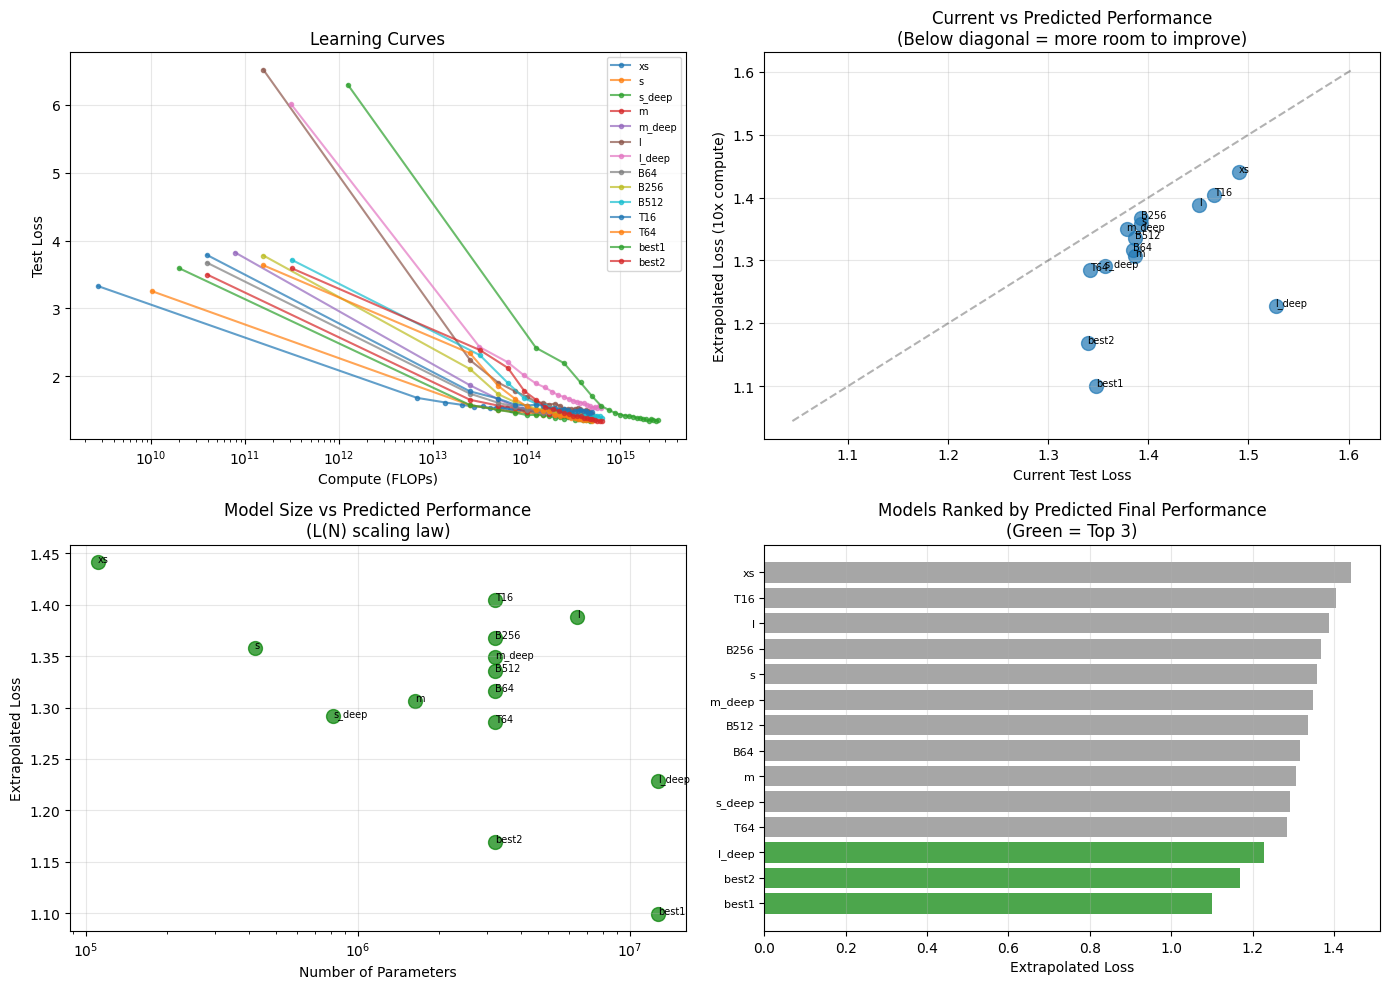

In [32]:
# This section:
# 1. Imports curve_fit (needed for fitting)
# 2. Fits scaling laws to discover the exponents
# 3. Extrapolates to predict best model at convergence
# 4. Creates visualizations

from scipy.optimize import curve_fit

# Fit scaling laws to our data
# This discovers the power-law exponents (αN, αS) specific to our data
alpha_N = fit_scaling_laws(results)

# Extrapolate to predict best model
# Uses fitted scaling laws to predict which model will perform best
# when trained to convergence (with 10x more compute)
results_sorted = extrapolate_performance(results, extrapolate_factor=10)

# Visualize results
# Generates plots showing learning curves, scaling relationships, and rankings
plot_scaling_analysis(results, results_sorted)

# Results

In [33]:
print(f"\n{'#'*70}")
print(f"SCALING LAW PREDICTION")
print(f"{'#'*70}\n")

# ==========================================================================
# IDENTIFY BEST MODEL
# ==========================================================================
# The model with lowest extrapolated loss is predicted to be best at convergence

best = results_sorted[0]

print(f"PREDICTED BEST MODEL: {best['name']}")
print(f"  Architecture: d_model={best['d_model']}, n_layers={best['n_layers']}, n_heads={best['n_heads']}")
print(f"  Training: B={best['B']}, T={best['T']}")
print(f"  Parameters: {best['n_params']:,}")
print(f"  Current Loss: {best['final_test_loss']:.4f}")
print(f"  Extrapolated Loss: {best['extrapolated_loss']:.4f}")
print(f"  Asymptotic Loss (L∞): {best.get('L_inf', best['final_test_loss']):.4f}")

# Show top 3 models
print(f"\nTop 3 predicted models:")
for i, r in enumerate(results_sorted[:3]):
    print(f"  {i+1}. {r['name']}: extrap_loss={r['extrapolated_loss']:.4f}")


######################################################################
SCALING LAW PREDICTION
######################################################################

PREDICTED BEST MODEL: best1
  Architecture: d_model=512, n_layers=4, n_heads=8
  Training: B=256, T=64
  Parameters: 12,695,552
  Current Loss: 1.3478
  Extrapolated Loss: 1.0996
  Asymptotic Loss (L∞): 1.0202

Top 3 predicted models:
  1. best1: extrap_loss=1.0996
  2. best2: extrap_loss=1.1689
  3. l_deep: extrap_loss=1.2283


# Generation

In [34]:
# ==========================================================================
# GENERATE TEXT WITH THE PREDICTED BEST MODEL
# ==========================================================================
# Use the model that scaling laws predict will perform best

# Get the best model's parameters
best_params = trained_models[best['name']]

# Recreate the model architecture (needed for generation)
best_model, _ = create_train_state(
    key, vocab_size, best['d_model'], best['n_layers'], best['n_heads'], max_len
)

# Set up generation
seed = 42
rng = jax.random.PRNGKey(seed)

# Starting prompt
prompt = "hello my fri"

# Encode prompt to integers
prompt_int = jnp.array(
    [[char_to_int.get(c, len(char_set)) for c in prompt.lower()[:64]]], 
    dtype=jnp.int32
)

# Generate text
gen_len = 200  # Number of characters to generate

out_ids = generation.generate_tokens(
    best_model, 
    best_params, 
    rng, 
    prompt_int, 
    gen_len, 
    block_size=64,
    temperature=0.7,  # Controls randomness (lower = more deterministic)
    sample=True       # Sample from distribution vs greedy decoding
)

# Decode generated integers back to text
generated_text = ''.join(int_to_char.get(int(x), '?') for x in list(out_ids[0]))

print(f"\nGenerated text from best model ({best['name']}):")
print("-" * 50)
print(prompt + generated_text)


Generated text from best model (best1):
--------------------------------------------------
hello my friend and important the pitch of languages and formers communications are set upon university in the part of the contender of science might double johannes for that the game rules were designed to reach
